# 02 - Dataset Preparation for YOLO26s

1. Load original annotations
2. Load fixed class mapping
3. Identify invalid/orphan records
4. Create cleaned annotation DataFrames
5. Convert:
      xmin, ymin, xmax, ymax
             ↓
      YOLO normalized format
6. Create:
      images/train
      images/val
      images/test
      labels/train
      labels/val
      labels/test
7. Copy images
8. Write YOLO labels
9. Create data.yaml
10. Verify prepared dataset
11. Visualize converted labels

In [2]:
%pip install PyYAML

  Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl.metadata (2.4 kB)
Using cached pyyaml-6.0.3-cp314-cp314-win_amd64.whl (156 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from matplotlib.patches import Rectangle
import shutil
import random
import yaml

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Define Project and Dataset Paths

The original dataset downloaded from Roboflow is stored under:

`data/dataset/`

It contains:

- `train/`
- `valid/`
- `test/`

Each split contains images and a Roboflow CSV annotation file.

The converted YOLO dataset will be generated separately under:

`data/yolo_dataset/`

In [5]:
# Project root
PROJECT_ROOT = Path.cwd().parent

# Original Roboflow dataset
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"

TRAIN_DIR = DATASET_DIR / "train"
VALID_DIR = DATASET_DIR / "valid"
TEST_DIR = DATASET_DIR / "test"

# Prepared YOLO dataset
YOLO_DATASET_DIR = PROJECT_ROOT / "data" / "yolo_dataset"

# YOLO directories
YOLO_IMAGES_DIR = YOLO_DATASET_DIR / "images"
YOLO_LABELS_DIR = YOLO_DATASET_DIR / "labels"

YOLO_TRAIN_IMAGES = YOLO_IMAGES_DIR / "train"
YOLO_VAL_IMAGES = YOLO_IMAGES_DIR / "val"
YOLO_TEST_IMAGES = YOLO_IMAGES_DIR / "test"

YOLO_TRAIN_LABELS = YOLO_LABELS_DIR / "train"
YOLO_VAL_LABELS = YOLO_LABELS_DIR / "val"
YOLO_TEST_LABELS = YOLO_LABELS_DIR / "test"

print("Project root:")
print(PROJECT_ROOT)

print("\nOriginal dataset:")
print(DATASET_DIR)

print("\nPrepared YOLO dataset:")
print(YOLO_DATASET_DIR)

Project root:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-

Original dataset:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset

Prepared YOLO dataset:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset


In [6]:
# Verify original dataset structure

paths_to_check = {
    "Dataset": DATASET_DIR,
    "Train": TRAIN_DIR,
    "Validation": VALID_DIR,
    "Test": TEST_DIR,
}

print("ORIGINAL DATASET STRUCTURE\n")

for name, path in paths_to_check.items():
    print(f"{name:12}: {'FOUND' if path.exists() else 'MISSING'}")
    print(f"              {path}")

ORIGINAL DATASET STRUCTURE

Dataset     : FOUND
              c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset
Train       : FOUND
              c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\train
Validation  : FOUND
              c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\valid
Test        : FOUND
              c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\test


## 3. Load Original Annotation Files

Roboflow exported the annotations in CSV format.

Each annotation contains:

- filename
- image width
- image height
- class
- xmin
- ymin
- xmax
- ymax

These bounding boxes are currently represented using Pascal VOC style
pixel coordinates.

They will later be converted into YOLO normalized coordinates.

In [7]:
# Locate annotation CSV files automatically

def find_annotation_csv(split_dir):
    csv_files = list(split_dir.glob("*.csv"))
    
    if len(csv_files) == 0:
        raise FileNotFoundError(
            f"No CSV annotation file found in {split_dir}"
        )
    
    if len(csv_files) > 1:
        print(f"Warning: multiple CSV files found in {split_dir}")
        print(csv_files)
    
    return csv_files[0]


TRAIN_CSV = find_annotation_csv(TRAIN_DIR)
VALID_CSV = find_annotation_csv(VALID_DIR)
TEST_CSV = find_annotation_csv(TEST_DIR)

print("Train CSV:", TRAIN_CSV)
print("Validation CSV:", VALID_CSV)
print("Test CSV:", TEST_CSV)

Train CSV: c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\train\_annotations.csv
Validation CSV: c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\valid\_annotations.csv
Test CSV: c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\dataset\test\_annotations.csv


In [8]:
# Load annotations

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Annotation files loaded successfully.\n")

print(f"Train annotations      : {len(train_df)}")
print(f"Validation annotations : {len(valid_df)}")
print(f"Test annotations       : {len(test_df)}")

Annotation files loaded successfully.

Train annotations      : 5590
Validation annotations : 1641
Test annotations       : 869


In [9]:
# Verify annotation columns

REQUIRED_COLUMNS = [
    "filename",
    "width",
    "height",
    "class",
    "xmin",
    "ymin",
    "xmax",
    "ymax"
]

for split_name, df in {
    "Train": train_df,
    "Validation": valid_df,
    "Test": test_df
}.items():
    
    missing_columns = [
        col for col in REQUIRED_COLUMNS
        if col not in df.columns
    ]
    
    print(f"{split_name}:")
    
    if missing_columns:
        print("  Missing columns:", missing_columns)
    else:
        print("  All required annotation columns are present.")

Train:
  All required annotation columns are present.
Validation:
  All required annotation columns are present.
Test:
  All required annotation columns are present.


## 4. Load the Fixed Class Mapping

The dataset contains 37 object classes.

A fixed class-to-ID mapping is used for the entire project.

The same mapping must be used for:

- training
- validation
- testing
- YOLO labels
- `data.yaml`
- model evaluation
- real-time detection

In [10]:
# Fixed class mapping

CLASS_NAMES = [
    "Battery",
    "Blood-Pressure-Monitor",
    "Boiler",
    "Clothes-Iron",
    "Coffee-Machine",
    "Computer-Keyboard",
    "Computer-Mouse",
    "Cooling-Display",
    "Desktop-PC",
    "Digital-Oscilloscope",
    "Drone",
    "Electric-Guitar",
    "Electronic-Keyboard",
    "Flashlight",
    "Flat-Panel-Monitor",
    "Flat-Panel-TV",
    "Glucose-Meter",
    "HDD",
    "Laptop",
    "Microwave",
    "Music-Player",
    "Oven",
    "PCB",
    "Photovoltaic-Panel",
    "Projector",
    "Refrigerator",
    "Rotary-Mower",
    "Router",
    "Server",
    "Smartphone",
    "Smoke-Detector",
    "Straight-Tube-Fluorescent-Lamp",
    "Street-Lamp",
    "TV-Remote-Control",
    "Telephone-Set",
    "USB-Flash-Drive",
    "Washing-Machine"
]

CLASS_TO_ID = {
    class_name: class_id
    for class_id, class_name in enumerate(CLASS_NAMES)
}

print("Number of classes:", len(CLASS_NAMES))

print("\nClass mapping:")
for class_id, class_name in enumerate(CLASS_NAMES):
    print(f"{class_id:2d}: {class_name}")

Number of classes: 37

Class mapping:
 0: Battery
 1: Blood-Pressure-Monitor
 2: Boiler
 3: Clothes-Iron
 4: Coffee-Machine
 5: Computer-Keyboard
 6: Computer-Mouse
 7: Cooling-Display
 8: Desktop-PC
 9: Digital-Oscilloscope
10: Drone
11: Electric-Guitar
12: Electronic-Keyboard
13: Flashlight
14: Flat-Panel-Monitor
15: Flat-Panel-TV
16: Glucose-Meter
17: HDD
18: Laptop
19: Microwave
20: Music-Player
21: Oven
22: PCB
23: Photovoltaic-Panel
24: Projector
25: Refrigerator
26: Rotary-Mower
27: Router
28: Server
29: Smartphone
30: Smoke-Detector
31: Straight-Tube-Fluorescent-Lamp
32: Street-Lamp
33: TV-Remote-Control
34: Telephone-Set
35: USB-Flash-Drive
36: Washing-Machine


In [11]:
# Verify class consistency across splits

for split_name, df in {
    "Train": train_df,
    "Validation": valid_df,
    "Test": test_df
}.items():
    
    dataset_classes = set(df["class"].unique())
    expected_classes = set(CLASS_NAMES)
    
    missing = expected_classes - dataset_classes
    extra = dataset_classes - expected_classes
    
    print(f"\n{split_name}")
    print("-" * 40)
    print("Number of classes:", len(dataset_classes))
    print("Missing classes:", missing if missing else "None")
    print("Unexpected classes:", extra if extra else "None")


Train
----------------------------------------
Number of classes: 37
Missing classes: None
Unexpected classes: None

Validation
----------------------------------------
Number of classes: 37
Missing classes: None
Unexpected classes: None

Test
----------------------------------------
Number of classes: 37
Missing classes: None
Unexpected classes: None


## 5. Identify Invalid and Orphan Annotation Records

An orphan annotation occurs when an annotation exists in the CSV but the
corresponding image file is not present in the split directory.

The original dataset contains one known training orphan annotation.

This record will NOT be manually deleted from the original dataset.

Instead, it will be excluded when creating the prepared YOLO dataset.

In [13]:
IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}


def get_actual_image_names(image_dir):
    return {
        path.name
        for path in image_dir.iterdir()
        if path.is_file()
        and path.suffix.lower() in IMAGE_EXTENSIONS
    }


def find_orphan_annotations(df, image_dir):
    actual_images = get_actual_image_names(image_dir)
    
    annotated_images = set(df["filename"].astype(str))
    
    missing_images = sorted(
        annotated_images - actual_images
    )
    
    return missing_images


missing_train = find_orphan_annotations(train_df, TRAIN_DIR)
missing_valid = find_orphan_annotations(valid_df, VALID_DIR)
missing_test = find_orphan_annotations(test_df, TEST_DIR)

print("ORPHAN ANNOTATION CHECK")
print("=" * 50)

print("Train:", len(missing_train))
print("Validation:", len(missing_valid))
print("Test:", len(missing_test))

if missing_train:
    print("\nMissing training image(s):")
    for filename in missing_train:
        print(filename)

if missing_valid:
    print("\nMissing validation image(s):")
    for filename in missing_valid:
        print(filename)

if missing_test:
    print("\nMissing test image(s):")
    for filename in missing_test:
        print(filename)

ORPHAN ANNOTATION CHECK
Train: 1
Validation: 0
Test: 0

Missing training image(s):
asus-ax6000-wifi-6-gaming-router-rt-ax88u-dual-band-gigabit-wireless-router-8-gb-ports-gaming-streaming-aimesh-compatible-included-lifetime-019c00bf4f2e4efcb694aadb55131da9_jpeg.rf.2afb1fc41b5585a0dd70c1ee17921e45.jpg


In [14]:
# Display annotation records referring to missing images

for split_name, df, missing_names in [
    ("Train", train_df, missing_train),
    ("Validation", valid_df, missing_valid),
    ("Test", test_df, missing_test)
]:
    
    if missing_names:
        print(f"\n===== {split_name} ORPHAN RECORDS =====")
        
        orphan_records = df[
            df["filename"].isin(missing_names)
        ]
        
        display(orphan_records)


===== Train ORPHAN RECORDS =====


,filename,width,height,class,xmin,ymin,xmax,ymax
2855,asus-ax6000-wifi-6-gaming-router-rt-ax88u-dual...,640,640,Router,18,147,625,495


## 6. Validate Bounding Box Annotations

Each bounding box must satisfy:

- xmin >= 0
- ymin >= 0
- xmax <= image width
- ymax <= image height
- xmax > xmin
- ymax > ymin

Invalid bounding boxes will be identified before conversion to YOLO format.

In [15]:
def find_invalid_bboxes(df):
    invalid = pd.Series(False, index=df.index)
    
    invalid |= df["xmin"] < 0
    invalid |= df["ymin"] < 0
    invalid |= df["xmax"] > df["width"]
    invalid |= df["ymax"] > df["height"]
    invalid |= df["xmax"] <= df["xmin"]
    invalid |= df["ymax"] <= df["ymin"]
    
    return df[invalid].copy()


invalid_train = find_invalid_bboxes(train_df)
invalid_valid = find_invalid_bboxes(valid_df)
invalid_test = find_invalid_bboxes(test_df)

print("INVALID BOUNDING BOX CHECK")
print("=" * 50)

print("Train:", len(invalid_train))
print("Validation:", len(invalid_valid))
print("Test:", len(invalid_test))

INVALID BOUNDING BOX CHECK
Train: 0
Validation: 0
Test: 0


In [16]:
# Check exact duplicate annotation rows

for split_name, df in {
    "Train": train_df,
    "Validation": valid_df,
    "Test": test_df
}.items():
    
    duplicate_count = df.duplicated().sum()
    
    print(f"{split_name} duplicate annotation rows: {duplicate_count}")

Train duplicate annotation rows: 0
Validation duplicate annotation rows: 1
Test duplicate annotation rows: 0


## 7. Create Cleaned Annotation DataFrames

The cleaning rules are:

1. Remove annotation records whose image does not exist.
2. Remove records with invalid bounding boxes.
3. Remove records containing unknown classes.
4. Keep the original Roboflow dataset unchanged.
5. Use the cleaned DataFrames only for YOLO dataset generation.

In [17]:
def clean_annotations(df, image_dir):
    df = df.copy()
    
    # Ensure filename is treated as string
    df["filename"] = df["filename"].astype(str)
    
    # Existing images
    actual_images = get_actual_image_names(image_dir)
    
    # 1. Remove orphan annotations
    valid_image_mask = df["filename"].isin(actual_images)
    
    # 2. Valid class
    valid_class_mask = df["class"].isin(CLASS_TO_ID)
    
    # 3. Valid bounding boxes
    valid_bbox_mask = (
        (df["xmin"] >= 0) &
        (df["ymin"] >= 0) &
        (df["xmax"] <= df["width"]) &
        (df["ymax"] <= df["height"]) &
        (df["xmax"] > df["xmin"]) &
        (df["ymax"] > df["ymin"])
    )
    
    clean_df = df[
        valid_image_mask &
        valid_class_mask &
        valid_bbox_mask
    ].copy()
    
    return clean_df


clean_train_df = clean_annotations(train_df, TRAIN_DIR)
clean_valid_df = clean_annotations(valid_df, VALID_DIR)
clean_test_df = clean_annotations(test_df, TEST_DIR)

print("CLEANING SUMMARY")
print("=" * 60)

for name, original, cleaned in [
    ("Train", train_df, clean_train_df),
    ("Validation", valid_df, clean_valid_df),
    ("Test", test_df, clean_test_df)
]:
    print(
        f"{name:12} | "
        f"Original: {len(original):5d} | "
        f"Cleaned: {len(cleaned):5d} | "
        f"Removed: {len(original) - len(cleaned):5d}"
    )

CLEANING SUMMARY
Train        | Original:  5590 | Cleaned:  5589 | Removed:     1
Validation   | Original:  1641 | Cleaned:  1641 | Removed:     0
Test         | Original:   869 | Cleaned:   869 | Removed:     0


In [18]:
def verify_no_orphans(df, image_dir):
    actual_images = get_actual_image_names(image_dir)
    remaining_orphans = set(df["filename"]) - actual_images
    return sorted(remaining_orphans)


print("REMAINING ORPHAN CHECK")
print("=" * 50)

for name, df, image_dir in [
    ("Train", clean_train_df, TRAIN_DIR),
    ("Validation", clean_valid_df, VALID_DIR),
    ("Test", clean_test_df, TEST_DIR)
]:
    remaining = verify_no_orphans(df, image_dir)
    print(f"{name}: {len(remaining)}")

REMAINING ORPHAN CHECK
Train: 0
Validation: 0
Test: 0


## 8. Convert Pascal VOC Bounding Boxes to YOLO Format

Original format:

`xmin, ymin, xmax, ymax`

YOLO requires:

`class_id, x_center, y_center, width, height`

All coordinates are normalized between 0 and 1.

For an image with width `W` and height `H`:

x_center = ((xmin + xmax) / 2) / W

y_center = ((ymin + ymax) / 2) / H

box_width = (xmax - xmin) / W

box_height = (ymax - ymin) / H

In [19]:
def voc_to_yolo(row):
    image_width = float(row["width"])
    image_height = float(row["height"])
    
    xmin = float(row["xmin"])
    ymin = float(row["ymin"])
    xmax = float(row["xmax"])
    ymax = float(row["ymax"])
    
    # Center coordinates
    x_center = ((xmin + xmax) / 2.0) / image_width
    y_center = ((ymin + ymax) / 2.0) / image_height
    
    # Bounding box dimensions
    box_width = (xmax - xmin) / image_width
    box_height = (ymax - ymin) / image_height
    
    class_id = CLASS_TO_ID[row["class"]]
    
    return [
        class_id,
        x_center,
        y_center,
        box_width,
        box_height
    ]

In [20]:
# Test YOLO conversion using one training annotation

sample_row = clean_train_df.iloc[0]

print("Original annotation:")
display(sample_row.to_frame().T)

converted = voc_to_yolo(sample_row)

print("\nYOLO format:")
print(
    f"class_id={converted[0]}, "
    f"x_center={converted[1]:.6f}, "
    f"y_center={converted[2]:.6f}, "
    f"width={converted[3]:.6f}, "
    f"height={converted[4]:.6f}"
)

Original annotation:


,filename,width,height,class,xmin,ymin,xmax,ymax
0,000000299923_jpg.rf.33767390e161f2fccabd637c60...,640,640,Refrigerator,138,180,521,510



YOLO format:
class_id=25, x_center=0.514844, y_center=0.539062, width=0.598437, height=0.515625


## 9. Create YOLO Dataset Directory Structure

The prepared dataset follows the standard YOLO structure:

data/yolo_dataset/
│
├── images/
│   ├── train/
│   ├── val/
│   └── test/
│
├── labels/
│   ├── train/
│   ├── val/
│   └── test/
│
└── data.yaml

In [21]:



# Cell 27 — Code


# Create YOLO directory structure

YOLO_DIRECTORIES = [
    YOLO_TRAIN_IMAGES,
    YOLO_VAL_IMAGES,
    YOLO_TEST_IMAGES,
    YOLO_TRAIN_LABELS,
    YOLO_VAL_LABELS,
    YOLO_TEST_LABELS
]

for directory in YOLO_DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

print("YOLO directory structure created.")

for directory in YOLO_DIRECTORIES:
    print(directory)

YOLO directory structure created.
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\images\train
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\images\val
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\images\test
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\labels\train
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\labels\val
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\labels\test


## 10. Copy Valid Images and Generate YOLO Labels

For every valid image:

1. Copy the image into the appropriate YOLO `images/` directory.
2. Collect all annotations belonging to that image.
3. Convert every bounding box to YOLO format.
4. Write all objects into one `.txt` label file.

If an image contains multiple objects, all corresponding bounding boxes
are stored in the same label file.

In [22]:
def prepare_yolo_split(
    df,
    source_image_dir,
    destination_image_dir,
    destination_label_dir
):
    destination_image_dir.mkdir(parents=True, exist_ok=True)
    destination_label_dir.mkdir(parents=True, exist_ok=True)
    
    image_count = 0
    label_count = 0
    
    # Group annotations by image
    grouped = df.groupby("filename")
    
    for filename, image_annotations in grouped:
        
        source_image = source_image_dir / filename
        
        if not source_image.exists():
            continue
        
        destination_image = destination_image_dir / filename
        
        # Copy image
        shutil.copy2(source_image, destination_image)
        image_count += 1
        
        # Label filename
        label_filename = Path(filename).stem + ".txt"
        label_path = destination_label_dir / label_filename
        
        lines = []
        
        for _, row in image_annotations.iterrows():
            yolo_values = voc_to_yolo(row)
            
            class_id, x_center, y_center, box_width, box_height = yolo_values
            
            lines.append(
                f"{class_id} "
                f"{x_center:.6f} "
                f"{y_center:.6f} "
                f"{box_width:.6f} "
                f"{box_height:.6f}"
            )
            
            label_count += 1
        
        label_path.write_text(
            "\n".join(lines),
            encoding="utf-8"
        )
    
    return image_count, label_count

In [23]:
# Prepare Train
train_images_created, train_labels_created = prepare_yolo_split(
    clean_train_df,
    TRAIN_DIR,
    YOLO_TRAIN_IMAGES,
    YOLO_TRAIN_LABELS
)

# Prepare Validation
valid_images_created, valid_labels_created = prepare_yolo_split(
    clean_valid_df,
    VALID_DIR,
    YOLO_VAL_IMAGES,
    YOLO_VAL_LABELS
)

# Prepare Test
test_images_created, test_labels_created = prepare_yolo_split(
    clean_test_df,
    TEST_DIR,
    YOLO_TEST_IMAGES,
    YOLO_TEST_LABELS
)

print("YOLO CONVERSION COMPLETE")
print("=" * 60)

print(
    f"Train      : {train_images_created} images, "
    f"{train_labels_created} objects"
)

print(
    f"Validation : {valid_images_created} images, "
    f"{valid_labels_created} objects"
)

print(
    f"Test       : {test_images_created} images, "
    f"{test_labels_created} objects"
)

YOLO CONVERSION COMPLETE
Train      : 4990 images, 5589 objects
Validation : 1444 images, 1641 objects
Test       : 776 images, 869 objects


## 11. Create YOLO `data.yaml`

The `data.yaml` file defines:

- dataset location
- training images
- validation images
- test images
- number of classes
- class names

The same fixed class mapping used during conversion is stored here.

In [24]:
# Create data.yaml

yaml_data = {
    "path": ".",
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES
}

YAML_PATH = YOLO_DATASET_DIR / "data.yaml"

with open(YAML_PATH, "w", encoding="utf-8") as file:
    yaml.dump(
        yaml_data,
        file,
        sort_keys=False,
        allow_unicode=True
    )

print("data.yaml created:")
print(YAML_PATH)

print("\nContents:\n")

with open(YAML_PATH, "r", encoding="utf-8") as file:
    print(file.read())

data.yaml created:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\data.yaml

Contents:

path: .
train: images/train
val: images/val
test: images/test
nc: 37
names:
- Battery
- Blood-Pressure-Monitor
- Boiler
- Clothes-Iron
- Coffee-Machine
- Computer-Keyboard
- Computer-Mouse
- Cooling-Display
- Desktop-PC
- Digital-Oscilloscope
- Drone
- Electric-Guitar
- Electronic-Keyboard
- Flashlight
- Flat-Panel-Monitor
- Flat-Panel-TV
- Glucose-Meter
- HDD
- Laptop
- Microwave
- Music-Player
- Oven
- PCB
- Photovoltaic-Panel
- Projector
- Refrigerator
- Rotary-Mower
- Router
- Server
- Smartphone
- Smoke-Detector
- Straight-Tube-Fluorescent-Lamp
- Street-Lamp
- TV-Remote-Control
- Telephone-Set
- USB-Flash-Drive
- Washing-Machine



## 12. Verify the Prepared YOLO Dataset

The prepared dataset must satisfy:

- every image has a corresponding label file
- every label contains valid YOLO values
- every class ID is between 0 and 36
- every normalized coordinate is between 0 and 1
- train/validation/test directories exist
- the expected number of classes is 37

In [25]:
def verify_yolo_split(image_dir, label_dir):
    image_files = [
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]
    
    label_files = list(label_dir.glob("*.txt"))
    
    image_stems = {p.stem for p in image_files}
    label_stems = {p.stem for p in label_files}
    
    missing_labels = sorted(image_stems - label_stems)
    extra_labels = sorted(label_stems - image_stems)
    
    return {
        "images": len(image_files),
        "labels": len(label_files),
        "missing_labels": missing_labels,
        "extra_labels": extra_labels
    }


verification = {
    "Train": verify_yolo_split(
        YOLO_TRAIN_IMAGES,
        YOLO_TRAIN_LABELS
    ),
    "Validation": verify_yolo_split(
        YOLO_VAL_IMAGES,
        YOLO_VAL_LABELS
    ),
    "Test": verify_yolo_split(
        YOLO_TEST_IMAGES,
        YOLO_TEST_LABELS
    )
}

for split_name, result in verification.items():
    print(f"\n===== {split_name} =====")
    print("Images:", result["images"])
    print("Labels:", result["labels"])
    print("Images without labels:", len(result["missing_labels"]))
    print("Labels without images:", len(result["extra_labels"]))


===== Train =====
Images: 4990
Labels: 4990
Images without labels: 0
Labels without images: 0

===== Validation =====
Images: 1444
Labels: 1444
Images without labels: 0
Labels without images: 0

===== Test =====
Images: 776
Labels: 776
Images without labels: 0
Labels without images: 0


In [26]:
def verify_yolo_labels(label_dir):
    invalid_files = []
    total_objects = 0
    
    for label_file in label_dir.glob("*.txt"):
        
        with open(label_file, "r", encoding="utf-8") as file:
            lines = [
                line.strip()
                for line in file.readlines()
                if line.strip()
            ]
        
        for line_number, line in enumerate(lines, start=1):
            
            values = line.split()
            
            if len(values) != 5:
                invalid_files.append(
                    (label_file.name, line_number, "Incorrect number of values")
                )
                continue
            
            try:
                class_id = int(values[0])
                x_center = float(values[1])
                y_center = float(values[2])
                width = float(values[3])
                height = float(values[4])
            except ValueError:
                invalid_files.append(
                    (label_file.name, line_number, "Non-numeric value")
                )
                continue
            
            # Class ID validation
            if not (0 <= class_id < len(CLASS_NAMES)):
                invalid_files.append(
                    (label_file.name, line_number, "Invalid class ID")
                )
            
            # Coordinate validation
            if not (0 <= x_center <= 1):
                invalid_files.append(
                    (label_file.name, line_number, "Invalid x_center")
                )
            
            if not (0 <= y_center <= 1):
                invalid_files.append(
                    (label_file.name, line_number, "Invalid y_center")
                )
            
            if not (0 < width <= 1):
                invalid_files.append(
                    (label_file.name, line_number, "Invalid width")
                )
            
            if not (0 < height <= 1):
                invalid_files.append(
                    (label_file.name, line_number, "Invalid height")
                )
            
            total_objects += 1
    
    return invalid_files, total_objects


for split_name, label_dir in [
    ("Train", YOLO_TRAIN_LABELS),
    ("Validation", YOLO_VAL_LABELS),
    ("Test", YOLO_TEST_LABELS)
]:
    
    invalid, total = verify_yolo_labels(label_dir)
    
    print(f"\n{split_name}")
    print("-" * 40)
    print("Objects checked:", total)
    print("Invalid labels:", len(invalid))
    
    if invalid:
        print("First invalid records:")
        for item in invalid[:10]:
            print(item)


Train
----------------------------------------
Objects checked: 5589
Invalid labels: 0

Validation
----------------------------------------
Objects checked: 1641
Invalid labels: 0

Test
----------------------------------------
Objects checked: 869
Invalid labels: 0


## 13. Verify Class Distribution After Conversion

The class distribution should remain consistent with the cleaned
annotations.

This confirms that the conversion process did not accidentally remove
or alter object classes.

In [27]:
# Class distribution of cleaned annotations

print("CLEANED DATASET CLASS DISTRIBUTION")
print("=" * 70)

for split_name, df in [
    ("Train", clean_train_df),
    ("Validation", clean_valid_df),
    ("Test", clean_test_df)
]:
    
    print(f"\n===== {split_name} =====")
    
    distribution = (
        df["class"]
        .value_counts()
        .reindex(CLASS_NAMES, fill_value=0)
    )
    
    display(distribution.to_frame("Object Count"))

CLEANED DATASET CLASS DISTRIBUTION

===== Train =====


,Object Count
class,
Battery,180
Blood-Pressure-Monitor,131
Boiler,136
Clothes-Iron,143
Coffee-Machine,205
Computer-Keyboard,145
Computer-Mouse,147
Cooling-Display,145
Desktop-PC,150



===== Validation =====


,Object Count
class,
Battery,37
Blood-Pressure-Monitor,52
Boiler,43
Clothes-Iron,47
Coffee-Machine,50
Computer-Keyboard,40
Computer-Mouse,36
Cooling-Display,42
Desktop-PC,37



===== Test =====


,Object Count
class,
Battery,33
Blood-Pressure-Monitor,19
Boiler,30
Clothes-Iron,20
Coffee-Machine,33
Computer-Keyboard,22
Computer-Mouse,20
Cooling-Display,20
Desktop-PC,19


## 14. Visualize Converted YOLO Annotations

A sample of prepared images will be loaded from the YOLO dataset.

The YOLO normalized coordinates will be converted back into pixel
coordinates only for visualization.

This provides a visual check that:

- bounding boxes are correctly positioned
- class IDs correspond to the correct class names
- bounding boxes remain inside the image
- the Pascal VOC → YOLO conversion was successful

In [28]:
def read_yolo_labels(label_path):
    annotations = []
    
    with open(label_path, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            
            if not line:
                continue
            
            values = line.split()
            
            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            width = float(values[3])
            height = float(values[4])
            
            annotations.append(
                (
                    class_id,
                    x_center,
                    y_center,
                    width,
                    height
                )
            )
    
    return annotations

In [29]:
def visualize_yolo_samples(
    image_dir,
    label_dir,
    number_of_samples=6,
    seed=42
):
    image_files = [
        p for p in image_dir.iterdir()
        if p.is_file()
        and p.suffix.lower() in IMAGE_EXTENSIONS
    ]
    
    random.seed(seed)
    
    samples = random.sample(
        image_files,
        min(number_of_samples, len(image_files))
    )
    
    for image_path in samples:
        
        label_path = label_dir / f"{image_path.stem}.txt"
        
        if not label_path.exists():
            continue
        
        image = Image.open(image_path).convert("RGB")
        
        width, height = image.size
        
        fig, ax = plt.subplots(figsize=(8, 8))
        
        ax.imshow(image)
        
        annotations = read_yolo_labels(label_path)
        
        for class_id, xc, yc, bw, bh in annotations:
            
            box_width = bw * width
            box_height = bh * height
            
            x_min = (xc * width) - (box_width / 2)
            y_min = (yc * height) - (box_height / 2)
            
            rectangle = Rectangle(
                (x_min, y_min),
                box_width,
                box_height,
                fill=False,
                linewidth=2
            )
            
            ax.add_patch(rectangle)
            
            ax.text(
                x_min,
                max(0, y_min - 5),
                CLASS_NAMES[class_id],
                fontsize=9,
                backgroundcolor="white"
            )
        
        ax.set_title(image_path.name)
        ax.axis("off")
        plt.show()

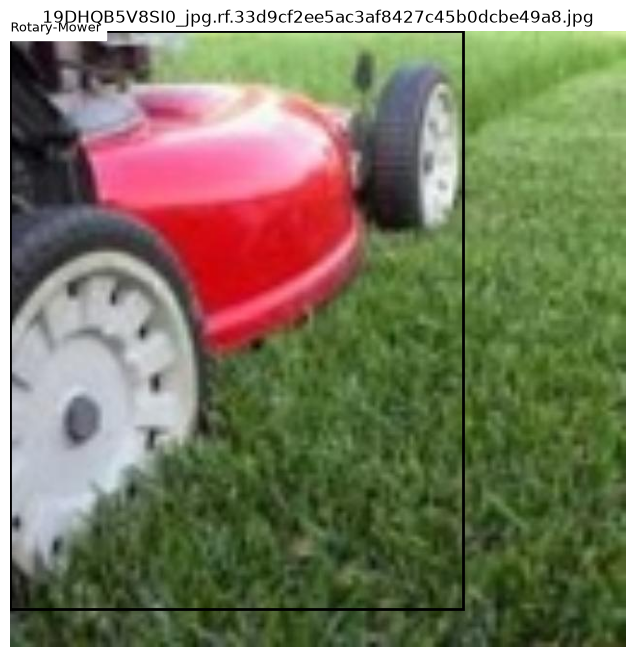

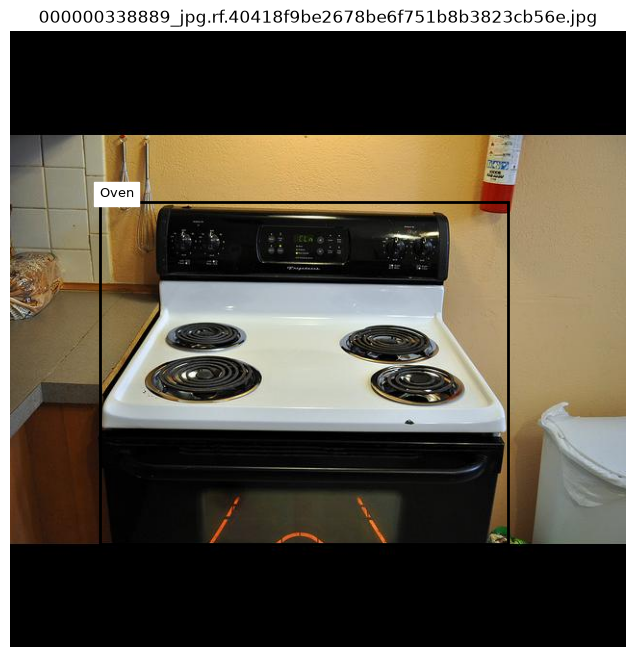

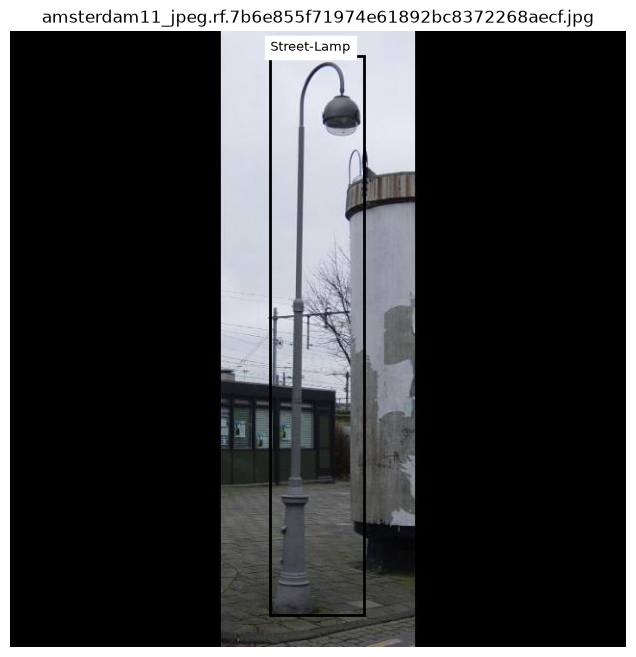

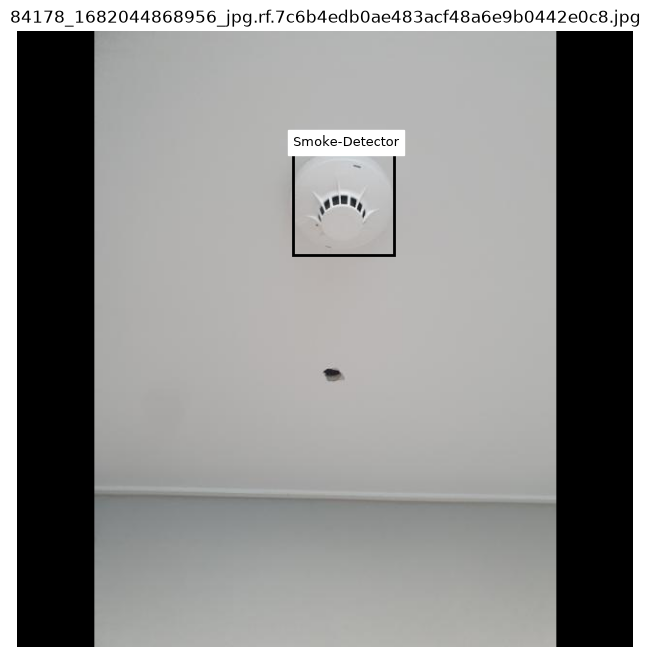

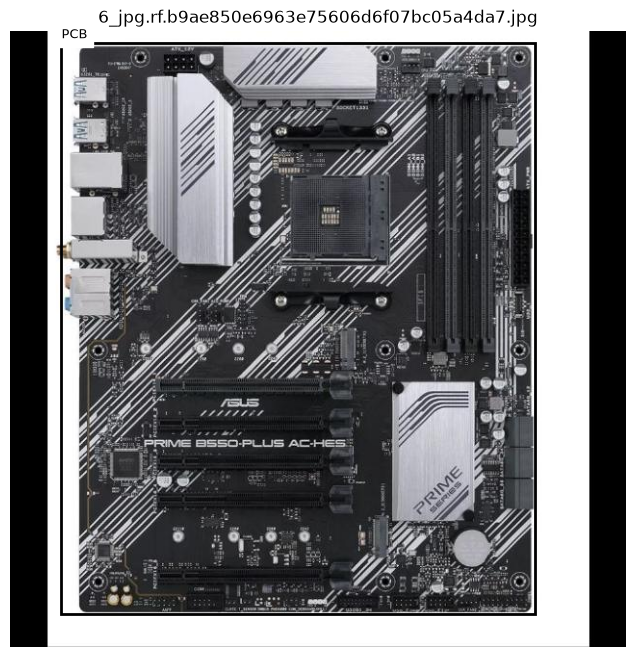

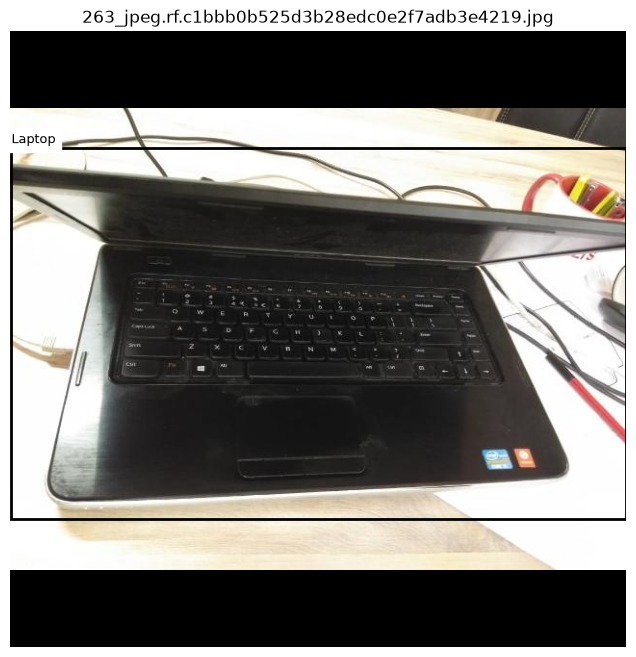

In [30]:
visualize_yolo_samples(
    YOLO_TRAIN_IMAGES,
    YOLO_TRAIN_LABELS,
    number_of_samples=6,
    seed=42
)

## 15. Final Prepared Dataset Summary

The final prepared YOLO dataset is now ready for model training.

Original dataset:

`data/dataset/`

Prepared dataset:

`data/yolo_dataset/`

The original dataset was not modified.

The prepared dataset contains:

- YOLO-format images
- YOLO-format label files
- fixed 37-class mapping
- `data.yaml`
- train/validation/test splits
- cleaned annotations

In [31]:
# Final dataset preparation summary

summary_rows = []

for split_name, image_dir, label_dir, df in [
    ("Train", YOLO_TRAIN_IMAGES, YOLO_TRAIN_LABELS, clean_train_df),
    ("Validation", YOLO_VAL_IMAGES, YOLO_VAL_LABELS, clean_valid_df),
    ("Test", YOLO_TEST_IMAGES, YOLO_TEST_LABELS, clean_test_df)
]:
    
    image_count = len([
        p for p in image_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])
    
    label_count = len(list(label_dir.glob("*.txt")))
    
    object_count = len(df)
    
    summary_rows.append({
        "Split": split_name,
        "Images": image_count,
        "Label Files": label_count,
        "Objects": object_count,
        "Classes": df["class"].nunique()
    })


final_summary_df = pd.DataFrame(summary_rows)

display(final_summary_df)

print("\n========== FINAL DATASET PREPARATION SUMMARY ==========")

print("Number of classes:", len(CLASS_NAMES))
print("Original training annotations:", len(train_df))
print("Cleaned training annotations:", len(clean_train_df))
print("Removed orphan/invalid training records:",
      len(train_df) - len(clean_train_df))

print("\nPrepared YOLO dataset:")
print(YOLO_DATASET_DIR)

print("\ndata.yaml:")
print(YAML_PATH)

print("\nDataset preparation completed successfully.")

,Split,Images,Label Files,Objects,Classes
0,Train,4990,4990,5589,37
1,Validation,1444,1444,1641,37
2,Test,776,776,869,37



========== FINAL DATASET PREPARATION SUMMARY ==========
Number of classes: 37
Original training annotations: 5590
Cleaned training annotations: 5589
Removed orphan/invalid training records: 1

Prepared YOLO dataset:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset

data.yaml:
c:\Users\USER\Desktop\computer vision\electronic-waste-detection-and-classification-for-automated-recycling-system-\data\yolo_dataset\data.yaml

Dataset preparation completed successfully.
